In [7]:
import numpy as np
import pandas as pd

In [8]:
df = pd.read_csv('spam.csv')

In [9]:
#df.head()  #to get top 5 records
df.sample(5) #to get random records

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
370,ham,Hello my boytoy ... Geeee I miss you already a...,NaN,NaN,NaN
5397,ham,That's necessarily respectful,NaN,NaN,NaN
1668,ham,"Yes..but they said its IT.,",NaN,NaN,NaN
4511,ham,Now project pa. After that only i can come.,NaN,NaN,NaN
238,ham,"New Theory: Argument wins d SITUATION, but los...",NaN,NaN,NaN


In [10]:
df.shape # (5572 sms(rows) , 5 col)

(5572, 5)

# DATA CLEANING

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [12]:
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True) #3 col are dropped bcz of lots of null values

In [13]:
df.sample(5)

,v1,v2
5226,ham,Prabha..i'm soryda..realy..frm heart i'm sory
4878,ham,Yeah just open chat and click friend lists. Th...
4773,ham,U repeat e instructions again. Wat's e road na...
3810,ham,Excellent! Wish we were together right now!
1528,ham,Hey what happen de. Are you alright.


In [14]:
df.rename(columns={'v1':'target','v2':'text'},inplace=True)   #renaming the columns
df.sample(2)

,target,text
2158,ham,I think you should go the honesty road. Call t...
5052,ham,Lmao you know me so well...


In [15]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [16]:
df['target'] = encoder.fit_transform(df['target'])

In [17]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [18]:
# checking missing values
df.isnull().sum()

target    0
text      0
dtype: int64

In [19]:
#checking duplicate values
df.duplicated().sum()

403

In [20]:
#remove duplicate
df = df.drop_duplicates(keep='first')

In [21]:
df.duplicated().sum()

0

In [22]:
df.shape

(5169, 2)

# EDA

In [23]:
df['target'].value_counts() # it will return total no. of spam and not-spam rows

target
0    4516
1     653
Name: count, dtype: int64

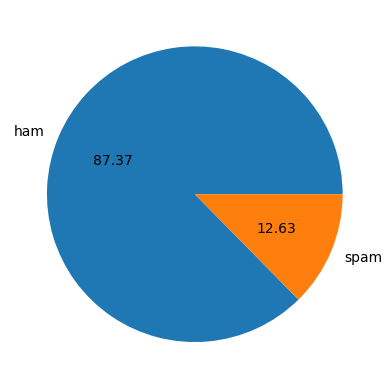

In [24]:
# # it will return total no. of spam and not-spam rows in form of pie-chart
import matplotlib.pyplot as plt 
plt.pie(df['target'].value_counts(),labels = ['ham','spam'],autopct="%0.2f")
plt.show()

In [25]:
#so here data is imbalanced as ham are too high

In [26]:
#now we are finding no. of characters,words,sentences in a SMS  using nltk(natural language toolkit library)
import nltk

In [27]:
# !pip install nltk

In [28]:
#nltk.download('punkt')  #nltk requires some dependencies to run,so download this
#nltk.download('punkt_tab')

In [29]:
df['num_characters'] = df['text'].apply(len) #new column is added for no. of characters
df.head()

,target,text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [30]:
df['num_words'] = df['text'].apply(lambda x:len(nltk.word_tokenize(x))) #new column is added for no. of words
df.head()

,target,text,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [31]:
df['num_sentences'] = df['text'].apply(lambda x:len(nltk.sent_tokenize(x))) #new column is added for no. of sentence
df.head()

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [32]:
df.describe() #it shows total count,mean,min,max,std values of a dataset

,target,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000,5169.000000
mean,0.126330,78.977945,18.455794,1.965564
std,0.332253,58.236293,13.324758,1.448541
min,0.000000,2.000000,1.000000,1.000000
25%,0.000000,36.000000,9.000000,1.000000
50%,0.000000,60.000000,15.000000,1.000000
75%,0.000000,117.000000,26.000000,2.000000
max,1.000000,910.000000,220.000000,38.000000


In [33]:
# for ham
df[df['target'] == 0][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [34]:
#for spam
df[df['target'] == 1][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [35]:
#now plot histogram for both classes - spam,ham
import seaborn as sns

<Axes: xlabel='num_characters', ylabel='Count'>

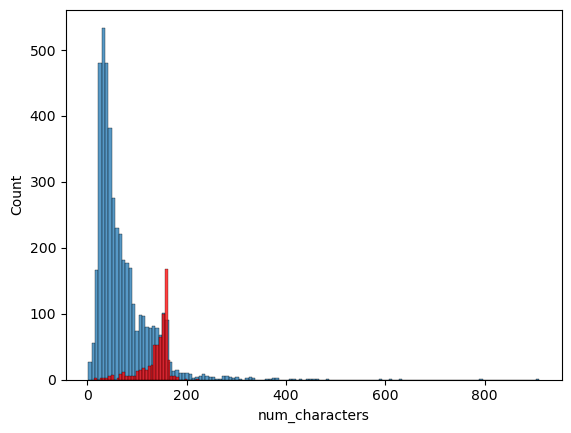

In [36]:
sns.histplot(df[df['target'] == 0]['num_characters'])   #for ham
sns.histplot(df[df['target'] == 1]['num_characters'],color='red')   #for spam

In [37]:
# from histogram, we analyzed that no. of characters are more in spam messages and also we can see that there are outliers present

<Axes: >

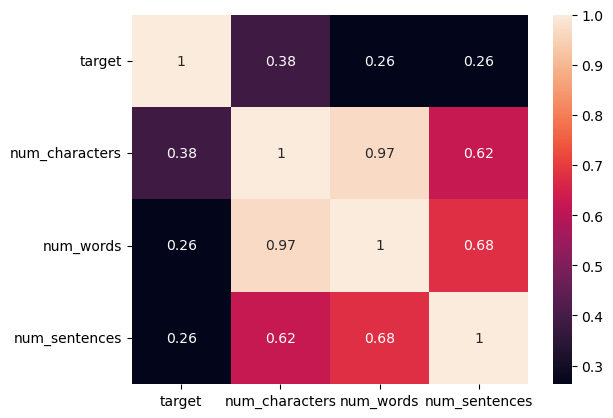

In [38]:
# now through seeing correlation coefficient in heat map, wee will choose num_character column.
sns.heatmap(df[['target','num_characters','num_words','num_sentences']].corr(),annot=True) 

# TEXT PREPROCESSING
- Lower case
- Tokenization (converting text into tokens)
- Removing special characters(%+-/-)
- Removing stop words(words that are used to form sentences but don't have any meaning like is,of,the) and punctuation(!,;")
- Stemming (removing the prefixe,suffixes from the words eg.-runs,running,run to run)

In [39]:
from nltk.corpus import stopwords
# nltk.download('stopwords')
stopwords.words('english')

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [40]:
import string 
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [41]:
from nltk.stem.porter import PorterStemmer  # for stemming
ps = PorterStemmer()
ps.stem('loving')

'love'

In [42]:
def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)
    y = []

    for i in text:
        if i.isalnum():
            y.append(i)

    text = y[:]
    y.clear()

    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)

    text = y[:]
    y.clear()

    for i in text:
        y.append(ps.stem(i))
    
    return " ".join(y)

In [43]:
transform_text('HI how are you %% 12 Nitish loving!?') #example

'hi 12 nitish love'

In [44]:
df['transformed_text'] = df['text'].apply(transform_text)

In [45]:
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [46]:
#now make an word cloud for spam,ham - which shows most occuring words visually in both 

In [47]:
#!pip install wordcloud
from wordcloud import WordCloud
wc = WordCloud(width=500,height=500,min_font_size=10,background_color='black')

In [48]:
# wordcloud for spam messages
spam_wc = wc.generate(df[df['target']==1]['transformed_text'].str.cat(sep=" "))

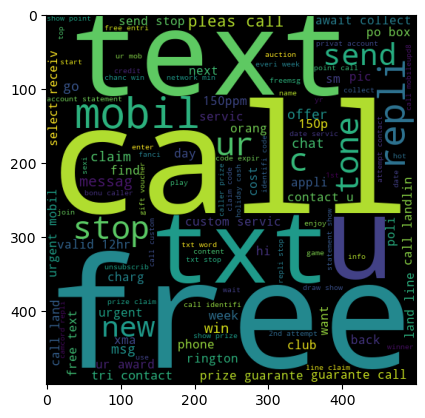

In [49]:
plt.imshow(spam_wc) #to display word_cloud for spam

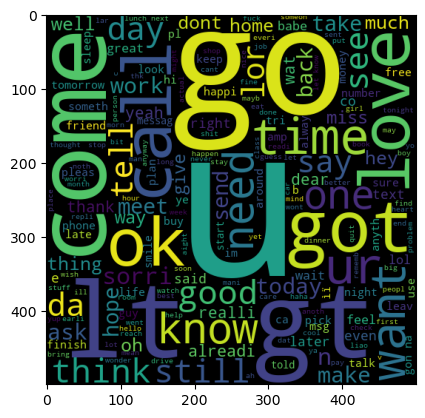

In [50]:
# wordcloud for ham messages
spam_wc = wc.generate(df[df['target']==0]['transformed_text'].str.cat(sep=" "))
plt.imshow(spam_wc) #to display word_cloud for spam

In [51]:
# now to see top-most words ,their occurence in both spam,ham

In [52]:
spam_corpus = []
for msg in df[df['target'] == 1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)

In [53]:
len(spam_corpus) # total words in spam

9939

In [54]:
from collections import  Counter
pd.DataFrame(Counter(spam_corpus).most_common(30))  #occurence of top 30 words for spam

,0,1
0,call,320
1,free,191
2,2,155
3,txt,141
4,text,122
5,u,119
6,ur,119
7,mobil,114
8,stop,104
9,repli,103


In [55]:
ham_corpus = []
for msg in df[df['target'] == 0]['transformed_text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)

len(ham_corpus) # total words in ham

35404

In [56]:
from collections import  Counter
pd.DataFrame(Counter(ham_corpus).most_common(30))  #occurence of top 30 words for ham

,0,1
0,u,883
1,go,404
2,get,349
3,gt,288
4,lt,287
5,2,284
6,come,275
7,got,236
8,know,236
9,like,234


# MODEL BUILDING

In [57]:
# 1 convert input(transformed_text) into vector using Bag of words method
# 2 then give this to model to check accuracy and all

In [203]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer #bag of words method,TF-ID used
cv = CountVectorizer()
tfidf = TfidfVectorizer(max_features=2000)

In [204]:
# X = cv.fit_transform(df['transformed_text']).toarray()
X = tfidf.fit_transform(df['transformed_text']).toarray()   #toarray() to convert spare->dense vector

In [205]:
X.shape  # (no. of rows = total number of text messages, no. of col =  total number of unique words)

(5169, 2000)

In [206]:
y = df['target'].values
y

array([0, 0, 1, ..., 0, 0, 0])

In [207]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [208]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [209]:
mnb = MultinomialNB()
svc = SVC(kernel='sigmoid')
rfc = RandomForestClassifier(n_estimators=50)
etc = ExtraTreesClassifier(n_estimators=50)

In [210]:
clfs = {
    'NB' : mnb,
    'SVC' : svc,
    'RF' : rfc,
    'ETC' : etc,
}

In [211]:
def train_classifier(clf,X_train,X_test,y_train,y_test):
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)

    return accuracy,precision

In [212]:
train_classifier(mnb,X_train,X_test,y_train,y_test)  # example for mnb

(0.97678916827853, 1.0)

In [213]:
accuracy_scores = []
precision_scores = []

for name,clf in clfs.items():
    current_accuracy,current_precision = train_classifier(clf,X_train,X_test,y_train,y_test)

    print("For ",name)
    print("Accuracy - ",current_accuracy)
    print("Precision - ",current_precision)

    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For  NB
Accuracy -  0.97678916827853
Precision -  1.0
For  SVC
Accuracy -  0.97678916827853
Precision -  0.975
For  RF
Accuracy -  0.97678916827853
Precision -  0.9913793103448276
For  ETC
Accuracy -  0.9758220502901354
Precision -  0.9669421487603306


In [214]:
performance_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_scores,'Precision':precision_scores}).sort_values('Precision',ascending=False)

In [215]:
performance_df

,Algorithm,Accuracy,Precision
0,NB,0.976789,1.000000
2,RF,0.976789,0.991379
1,SVC,0.976789,0.975000
3,ETC,0.975822,0.966942


In [216]:
# tfid method -> RF choosed

# Model improvement

In [217]:
# 1. can apply other algorithms
# 2. Can change the max_features parameter of TfIdf to improve model performance ( tfidf = TfidfVectorizer(max_features=3000) )
# 3. do feature scaling by using MIN-MAX scalar to get vector value ranges in 0-1 ,cannot use StandardScalar(Standardization) as it it gives range -1to1 but naive_bayes dont accept -ve values
# 4. can include no. of characters columns in X(independent-variable) to evaluate performance
# 5. can use Voting classifier (which is an combination of muliple different algo.)

# Saving the vectorized TF-IDF and model in file

In [218]:
import pickle
pickle.dump(tfidf,open('vectorizer.pkl','wb'))
pickle.dump(mnb,open('model.pkl','wb'))